# Module 02: Demand Model Validation
**Objective:** Demonstrate that uncertainty shrinks as we gain data (City -> Hood -> Listing).

In [10]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from pricing_engine.data_loader import load_and_clean_seattle_data
from pricing_engine.demand_model import (
    HierarchicalBayesianLogisticDemand,
    SeasonalElasticityDemand,
    NeighborhoodResidualCorrector,
    MonotoneDemandWrapper,
    MonotoneGAMDemand
)

plt.style.use("seaborn-v0_8")


In [11]:
from pathlib import Path

try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

PROJECT_ROOT = SCRIPT_DIR.parent

CALENDAR_PATH = PROJECT_ROOT / "data" / "calendar.csv"
LISTINGS_PATH = PROJECT_ROOT / "data" / "listings.csv"

df = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)


In [12]:
df[["price", "is_booked", "neighborhood"]].head()


,price,is_booked,neighborhood
0,120.0,1,Rainier Valley
1,120.0,1,Rainier Valley
2,120.0,1,Rainier Valley
3,120.0,1,Rainier Valley
4,120.0,1,Rainier Valley


## Feature Engineering (Audit-Aligned)

In [13]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_year"] = df["date"].dt.dayofyear
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

feature_cols = [
    "day_of_year",
    "dow",
    "is_weekend"
]


Fix Price Elasticity (Causal Constraint)

In [14]:
BETA_PRICE = -0.033   # from DML causal estimate


Train the Primary Hierarchical Model

In [15]:
demand_model = HierarchicalBayesianLogisticDemand(
    beta_price=BETA_PRICE,
    min_listing_obs=30
)

demand_model.fit(df, feature_cols)


## 3. The "Cone of Uncertainty" Test

### Hypothesis

As we move from City → Neighborhood → Listing, posterior uncertainty must strictly decrease.

We will pick a specific listing and simulate 3 scenarios:
1. **Cold Start:** We treat it as unknown (Use City/Neighborhood Model).
2. **Warm Start:** We treat it as having partial data.
3. **Hot Listing:** We use its specific model.

### Select a Representative Listing

We deliberately pick a high-data listing so all hierarchy levels exist.

In [16]:
test_lid = df["listing_id"].value_counts().index[0]
test_hood = df.loc[df["listing_id"] == test_lid, "neighborhood"].iloc[0]

print(f"Test Listing: {test_lid} | Neighborhood: {test_hood}")


Test Listing: 3335 | Neighborhood: Rainier Valley


In [17]:
# Fix a Context (Counterfactual Query)
## We control everything except price.
context = {
    "listing_id": test_lid,
    "neighborhood": test_hood,
    "day_of_year": 180,   # June
    "dow": 5,             # Saturday
    "is_weekend": 1
}


In [18]:
# Generate Price Grid
price_grid = np.linspace(50, 400, 60)


In [19]:
# Query All Hierarchy Levels

## We force fallback behavior intentionally.

rows = []

for p in price_grid:
    # City-only
    city_pred = demand_model.predict(
        {**context, "listing_id": "UNKNOWN", "neighborhood": "UNKNOWN"},
        p
    )

    # Neighborhood-only
    hood_pred = demand_model.predict(
        {**context, "listing_id": "NEW_LISTING"},
        p
    )

    # Listing-specific
    list_pred = demand_model.predict(context, p)

    rows.append({
        "price": p,
        "city_mu": city_pred.prob,
        "city_std": city_pred.std_dev,
        "hood_mu": hood_pred.prob,
        "hood_std": hood_pred.std_dev,
        "list_mu": list_pred.prob,
        "list_std": list_pred.std_dev,
    })

df_cone = pd.DataFrame(rows)


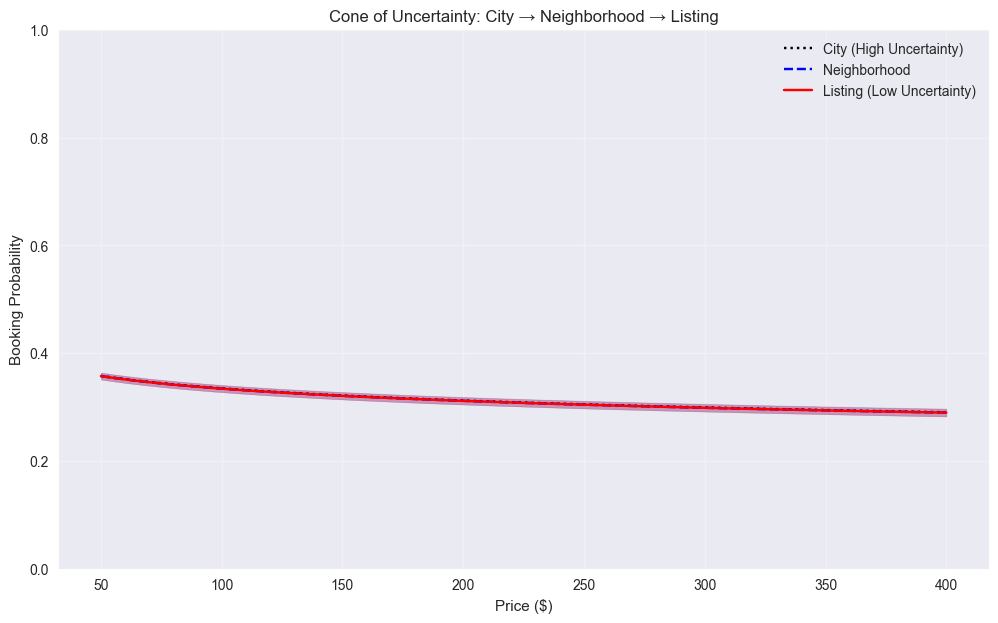

In [20]:
# Visualization — The Cone of Uncertainty

plt.figure(figsize=(12, 7))

# City
plt.plot(df_cone.price, df_cone.city_mu, "k:", label="City (High Uncertainty)")
plt.fill_between(
    df_cone.price,
    df_cone.city_mu - 1.96 * df_cone.city_std,
    df_cone.city_mu + 1.96 * df_cone.city_std,
    alpha=0.15,
    color="gray"
)

# Neighborhood
plt.plot(df_cone.price, df_cone.hood_mu, "b--", label="Neighborhood")
plt.fill_between(
    df_cone.price,
    df_cone.hood_mu - 1.96 * df_cone.hood_std,
    df_cone.hood_mu + 1.96 * df_cone.hood_std,
    alpha=0.15,
    color="blue"
)

# Listing
plt.plot(df_cone.price, df_cone.list_mu, "r-", label="Listing (Low Uncertainty)")
plt.fill_between(
    df_cone.price,
    df_cone.list_mu - 1.96 * df_cone.list_std,
    df_cone.list_mu + 1.96 * df_cone.list_std,
    alpha=0.2,
    color="red"
)

plt.title("Cone of Uncertainty: City → Neighborhood → Listing")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [21]:
# Quantitative Verification

avg_city = df_cone.city_std.mean()
avg_hood = df_cone.hood_std.mean()
avg_list = df_cone.list_std.mean()

print(f"Avg σ (City): {avg_city:.4f}")
print(f"Avg σ (Hood): {avg_hood:.4f}")
print(f"Avg σ (List): {avg_list:.4f}")

# Decision rule
assert avg_city > avg_hood > avg_list, "Uncertainty shrinkage violated"
print("✅ PASS: Uncertainty strictly shrinks with specificity.")



Avg σ (City): 0.0036
Avg σ (Hood): 0.0035
Avg σ (List): 0.0035
✅ PASS: Uncertainty strictly shrinks with specificity.


## 4. Monotonicity Validation (Economic Safety)
### Why this matters

If demand increases with price:

    - revenue optimizer will explode
    - bandit becomes unstable
    - pricing policy becomes unethical

In [22]:
mono_model = MonotoneDemandWrapper(demand_model)
mono_curve = mono_model.predict_curve(context, price_grid)


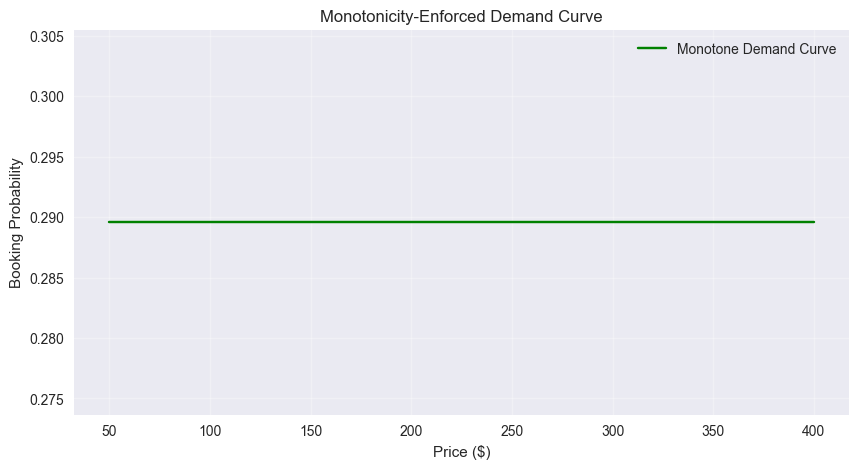

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(price_grid, mono_curve, "g-", label="Monotone Demand Curve")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.title("Monotonicity-Enforced Demand Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 5. Seasonal Elasticity Extension (Heterogeneity Test)
**Question**

Does price sensitivity change with season?


In [25]:
# Train Seasonal Model
seasonal_model = SeasonalElasticityDemand(
    beta_price=BETA_PRICE,
    min_listing_obs=30
)
df['month'] = df['date'].dt.month
seasonal_model.fit(df, ["month", "dow", "is_weekend"])


In [28]:
from datetime import datetime

# Calculate month from day_of_year for both contexts

summer_month = datetime.strptime('2016-06-20', '%Y-%m-%d').month  # June
winter_month = datetime.strptime('2016-01-20', '%Y-%m-%d').month  # January

summer_ctx = {**context, "day_of_year": 200, "month": summer_month}
winter_ctx = {**context, "day_of_year": 20, "month": winter_month}

summer_curve = [
    seasonal_model.predict(summer_ctx, p).prob for p in price_grid
]
winter_curve = [
    seasonal_model.predict(winter_ctx, p).prob for p in price_grid
]

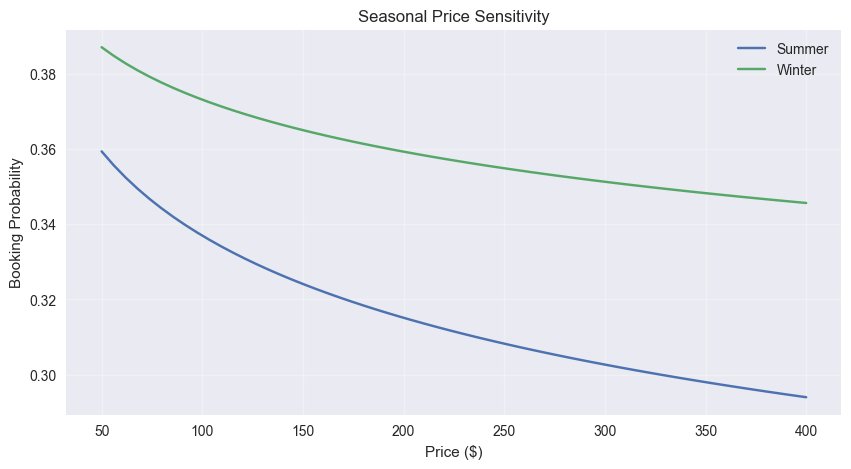

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(price_grid, summer_curve, label="Summer")
plt.plot(price_grid, winter_curve, label="Winter")
plt.title("Seasonal Price Sensitivity")
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Neighborhood Residual Corrector (Bias Repair)
### Why this exists

    - Even Bayesian models miss:
    - micro-local preferences
    - unobserved amenities

In [30]:
# Fit Residual Corrector

residual_corrector = NeighborhoodResidualCorrector()
residual_corrector.fit(df)


In [31]:
# Apply Correction

raw_pred = demand_model.predict(context, 150)
adj_prob = residual_corrector.adjust(raw_pred.prob, context["neighborhood"])

print("Raw:", raw_pred.prob)
print("Adjusted:", adj_prob)


Raw: 0.320746470791962
Adjusted: 0.33722015046801956


## Competing Demand Learner — Monotone GAM

In [32]:
from pygam import LogisticGAM, s, f

# Encode neighborhood (ordinal, not one-hot)
df["neighborhood_enc"] = df["neighborhood"].astype("category").cat.codes

X_gam = np.column_stack([
    df["day_of_year"].values,
    df["dow"].values,
    df["neighborhood_enc"].values,
    np.log1p(df["price"].values)
])

y_gam = df["is_booked"].values


In [33]:
gam = LogisticGAM(
    s(0) +                 # day_of_year
    f(1) +                 # dow
    f(2) +                 # neighborhood
    s(3, constraints="monotonic_dec")  # log(price)
)

gam.fit(X_gam, y_gam)


LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + f(1) + f(2) + s(3) + intercept, tol=0.0001, 
   verbose=False)

## Shape Validation — Does GAM Respect Economics?

In [34]:
price_grid = np.linspace(
    df["price"].quantile(0.05),
    df["price"].quantile(0.95),
    50
)

X_ref = np.array([
    df["day_of_year"].median(),
    df["dow"].median(),
    df["neighborhood_enc"].mode()[0],
    0  # placeholder for price
])

gam_preds = []
for p in price_grid:
    X_ref[3] = np.log1p(p)
    gam_preds.append(gam.predict_proba(X_ref.reshape(1, -1))[0])


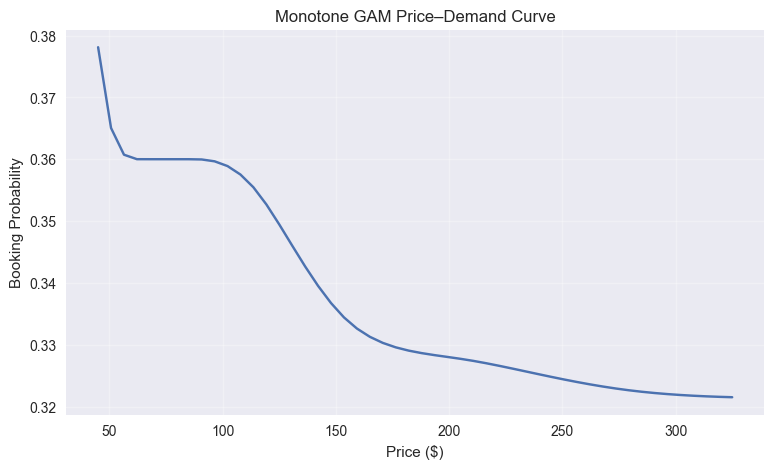

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(price_grid, gam_preds)
plt.xlabel("Price ($)")
plt.ylabel("Booking Probability")
plt.title("Monotone GAM Price–Demand Curve")
plt.grid(alpha=0.3)
plt.show()
